Install Dependencies

In [1]:

!pip install -q ultralytics
!pip install -q opencv-python
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 11.5 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Dataset Description

- Input: Leaf Images
- Ground Truth: Pixel-level segmentation masks
- Goal: Convert segmentation masks → detection labels for YOLO training


DOWNLOAD DATASET


In [ ]:
import os
from google.colab import userdata

# Replace these with your actual Kaggle credentials
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Now run your commands
!kaggle datasets download -d ankanghosh651/leaf-sengmentation-dataset-sam2-format
!unzip -q leaf-sengmentation-dataset-sam2-format.zip -d leaf-seg

Dataset URL: https://www.kaggle.com/datasets/ankanghosh651/leaf-sengmentation-dataset-sam2-format
License(s): MIT
  0% 0.00/51.5M [00:00<?, ?B/s]
100% 51.5M/51.5M [00:00<00:00, 986MB/s]


In [ ]:
import os
print(os.listdir())

['.config', 'leaf-sengmentation-dataset-sam2-format.zip', 'leaf-seg', 'sample_data']


In [ ]:
import os
print(os.listdir("leaf-seg"))

['leaf-seg']


In [ ]:
import os

for root, dirs, files in os.walk("leaf-seg"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("------")

Folder: leaf-seg
Subfolders: ['leaf-seg']
Files: []
------
Folder: leaf-seg/leaf-seg
Subfolders: ['images', 'masks']
Files: ['train.csv']
------
Folder: leaf-seg/leaf-seg/images
Subfolders: []
Files: ['00472.jpg', '00349.jpg', '00258.jpg', '00286.jpg', '00390.jpg']
------
Folder: leaf-seg/leaf-seg/masks
Subfolders: []
Files: ['00554.png', '00144.png', '00274.png', '00430.png', '00161.png']
------


Random Sample

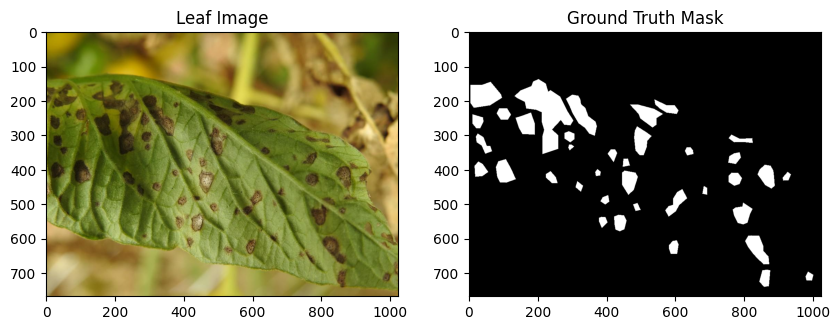

In [ ]:
data_dir = "leaf-seg/leaf-seg"
images_dir = os.path.join(data_dir, "images")
masks_dir = os.path.join(data_dir, "masks")

df = pd.read_csv(os.path.join(data_dir, "train.csv"))

row = df.sample(1).iloc[0]

img_path = os.path.join(images_dir, row["imageid"])
mask_path = os.path.join(masks_dir, row["maskid"])

image = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Leaf Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.show()

In [ ]:
df.head()

,imageid,maskid
0,00000.jpg,00000.png
1,00001.jpg,00001.png
2,00002.jpg,00002.png
3,00003.jpg,00003.png
4,00004.jpg,00004.png


## Converting Segmentation Masks → Bounding Boxes
We extract contours from masks and compute bounding rectangles.

Convert Masks → YOLO Format

In [ ]:


yolo_images = "yolo_dataset/images/train"
yolo_labels = "yolo_dataset/labels/train"

os.makedirs(yolo_images, exist_ok=True)
os.makedirs(yolo_labels, exist_ok=True)

for _, row in df.iterrows():

    img_path = os.path.join(images_dir, row["imageid"])
    mask_path = os.path.join(masks_dir, row["maskid"])

    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, 0)

    h, w = mask.shape

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label_lines = []

    for cnt in contours:
        if cv2.contourArea(cnt) < 50:
            continue

        x, y, bw, bh = cv2.boundingRect(cnt)

        xc = (x + bw/2) / w
        yc = (y + bh/2) / h
        bw /= w
        bh /= h

        label_lines.append(f"0 {xc} {yc} {bw} {bh}")

    cv2.imwrite(os.path.join(yolo_images, row["imageid"]), image)

    label_path = os.path.join(
        yolo_labels,
        row["imageid"].replace(".jpg",".txt")
    )

    with open(label_path, "w") as f:
        f.write("\n".join(label_lines))

Create YOLO Config

In [ ]:
%%writefile leaf.yaml
path: yolo_dataset
train: images/train
val: images/train

names:
  0: disease

Writing leaf.yaml


Train YOLOv8n

In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data="leaf.yaml",
    epochs=25,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=leaf.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c0f6633860>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model.val()

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2518.8±1177.9 MB/s, size: 110.1 KB)
val: Scanning /content/yolo_dataset/labels/train.cache... 588 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 308.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 4.4it/s 8.5s
                   all        588       4374      0.745      0.723      0.801      0.512
Speed: 1.7ms preprocess, 4.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c2a7bf2720>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

Download Lightweight SAM

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

Test On Random Image

In [ ]:
from segment_anything import sam_model_registry, SamPredictor

device = "cuda"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

predictor = SamPredictor(sam)

In [ ]:

# def automatic_segmentation(image_path):

#     image = cv2.imread(image_path)

#     if image is None:
#         raise ValueError("Image not found:", image_path)

#     image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#     results = model(image_rgb)
#     boxes = results[0].boxes.xyxy.cpu().numpy()

#     predictor.set_image(image_rgb)

#     final_mask = np.zeros(image_rgb.shape[:2])

#     for box in boxes:
#         with torch.no_grad():
#             masks, _, _ = predictor.predict(
#                 box=box.reshape(1,4),
#                 multimask_output=False
#             )

#         final_mask = np.logical_or(final_mask, masks[0])

#     return image_rgb, final_mask.astype(np.uint8)

In [ ]:
def automatic_segmentation(image_path):

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found:", image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # -------- YOLO Detection --------
    results = model(image_rgb)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("No detection.")
        return image_rgb, np.zeros(image_rgb.shape[:2])

    final_mask = np.zeros(image_rgb.shape[:2])

    for box in boxes:

        x1, y1, x2, y2 = map(int, box)

        crop = image[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)

        # -------- Disease color threshold (tighter brown range) --------
        lower = np.array([5, 80, 20])
        upper = np.array([25, 255, 200])
        disease_mask = cv2.inRange(hsv, lower, upper)

        kernel = np.ones((5,5), np.uint8)
        disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_OPEN, kernel)

        # -------- Foreground points via contour centers --------
        contours, _ = cv2.findContours(
            disease_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        fg_points = []

        for cnt in contours:
            if cv2.contourArea(cnt) < 30:
                continue

            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                fg_points.append([cx, cy])

        if len(fg_points) == 0:
            continue

        fg_points = np.array(fg_points)

        # -------- Background points near border --------
        border_mask = np.zeros_like(disease_mask)
        border_mask[0:10,:] = 1
        border_mask[-10:,:] = 1
        border_mask[:,0:10] = 1
        border_mask[:,-10:] = 1

        ys_bg, xs_bg = np.where(border_mask > 0)

        bg_count = min(10, len(xs_bg))
        bg_idx = np.random.choice(len(xs_bg), bg_count, replace=False)
        bg_points = np.array([[xs_bg[i], ys_bg[i]] for i in bg_idx])

        # -------- Combine prompts --------
        point_coords = np.vstack([fg_points, bg_points])
        point_labels = np.array([1]*len(fg_points) + [0]*len(bg_points))

        predictor.set_image(crop_rgb)

        with torch.no_grad():
            masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=False
            )

        mask_crop = masks[0]

        # Optional: smooth mask
        kernel = np.ones((7,7), np.uint8)
        mask_crop = cv2.morphologyEx(
            mask_crop.astype(np.uint8), cv2.MORPH_CLOSE, kernel
        )

        final_mask[y1:y2, x1:x2] = np.logical_or(
            final_mask[y1:y2, x1:x2],
            mask_crop
        )

    return image_rgb, final_mask.astype(np.uint8)

Test

In [ ]:
import random

In [ ]:
# image_folder = images_dir
# random_image = random.choice(os.listdir(image_folder))
# image_path = os.path.join(image_folder, random_image)

# print("Testing on:", image_path)

# img, mask = automatic_segmentation(image_path)

# plt.figure(figsize=(10,5))
# plt.subplot(1,2,1)
# plt.imshow(img)
# plt.title("Input Image")

# plt.subplot(1,2,2)
# plt.imshow(mask, cmap="gray")
# plt.title("Predicted Mask")
# plt.show()

Test On Random Image

Testing on: leaf-seg/leaf-seg/images/00504.jpg

0: 640x320 1 disease, 39.3ms
Speed: 2.9ms preprocess, 39.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 320)


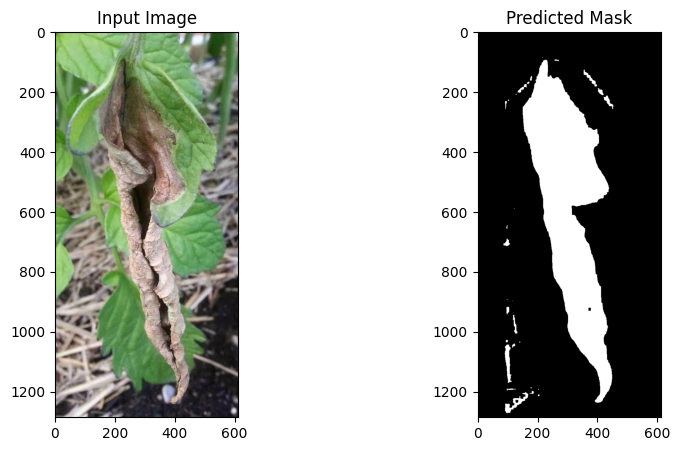

In [ ]:
image_folder = images_dir
random_image = random.choice(os.listdir(image_folder))
image_path = os.path.join(image_folder, random_image)

print("Testing on:", image_path)

img, mask = automatic_segmentation(image_path)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Mask")
plt.show()

In [ ]:
def calculate_disease_percentage(mask):
    disease_pixels = np.sum(mask > 0)
    total_pixels = mask.shape[0] * mask.shape[1]
    return (disease_pixels / total_pixels) * 100

percent = calculate_disease_percentage(mask)

print(f"Disease Area: {percent:.2f}%")

Disease Area: 19.99%


Evaluation Metrics

In [ ]:


def compute_iou(pred_mask, gt_mask):

    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return intersection / union


def compute_dice(pred_mask, gt_mask):

    pred = (pred_mask > 0).astype(np.uint8)
    gt = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred, gt).sum()

    denom = pred.sum() + gt.sum()

    if denom == 0:
        return 1.0

    return (2 * intersection) / denom

🔍 Evaluate On One Random Image

Evaluating: leaf-seg/leaf-seg/images/00525.jpg

0: 448x640 1 disease, 63.2ms
Speed: 3.5ms preprocess, 63.2ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)
IoU  : 0.6240
Dice : 0.7685


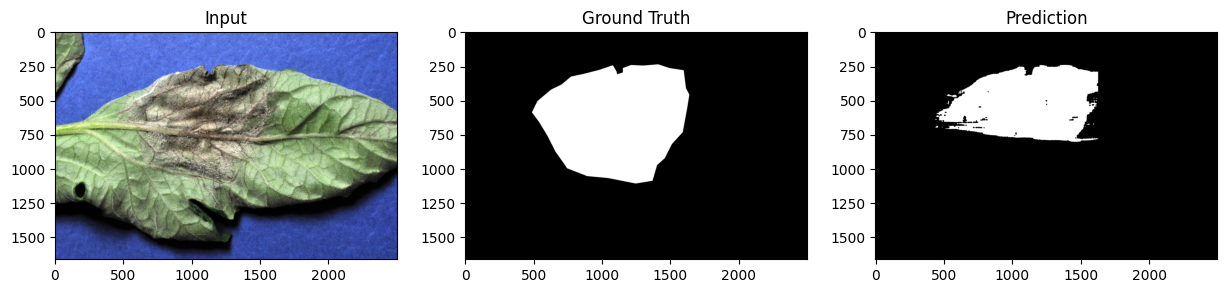

In [ ]:


row = df.sample(1).iloc[0]

image_path = os.path.join(images_dir, row["imageid"])
gt_mask_path = os.path.join(masks_dir, row["maskid"])

print("Evaluating:", image_path)

# Predict
img, pred_mask = automatic_segmentation(image_path)

# Load GT
gt_mask = cv2.imread(gt_mask_path, 0)

# Resize prediction if needed
if pred_mask.shape != gt_mask.shape:
    pred_mask = cv2.resize(
        pred_mask,
        (gt_mask.shape[1], gt_mask.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

iou = compute_iou(pred_mask, gt_mask)
dice = compute_dice(pred_mask, gt_mask)

print(f"IoU  : {iou:.4f}")
print(f"Dice : {dice:.4f}")

# Visualize
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input")

plt.subplot(1,3,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")

plt.show()

Full Dataset Evaluation

In [ ]:


num_samples = 100   # kept small and you may increase if GPU time allows

ious = []
dices = []

sample_df = df.sample(num_samples)

for _, row in sample_df.iterrows():

    image_path = os.path.join(images_dir, row["imageid"])
    gt_mask_path = os.path.join(masks_dir, row["maskid"])

    _, pred_mask = automatic_segmentation(image_path)
    gt_mask = cv2.imread(gt_mask_path, 0)

    if pred_mask.shape != gt_mask.shape:
        pred_mask = cv2.resize(
            pred_mask,
            (gt_mask.shape[1], gt_mask.shape[0]),
            interpolation=cv2.INTER_NEAREST
        )

    ious.append(compute_iou(pred_mask, gt_mask))
    dices.append(compute_dice(pred_mask, gt_mask))

print("===================================")
print(f"Average IoU  : {np.mean(ious):.4f}")
print(f"Average Dice : {np.mean(dices):.4f}")
print("===================================")


0: 640x640 4 diseases, 9.6ms
Speed: 3.7ms preprocess, 9.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 diseases, 6.8ms
Speed: 2.1ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 diseases, 6.9ms
Speed: 3.5ms preprocess, 6.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 disease, 6.2ms
Speed: 3.1ms preprocess, 6.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 disease, 5.9ms
Speed: 2.7ms preprocess, 5.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 6 diseases, 6.6ms
Speed: 3.8ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 diseases, 7.6ms
Speed: 3.7ms preprocess, 7.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x480 2 diseases, 6.9ms
Speed: 2.7ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640,